# Own Mission 1: Translation Efficiency (TE) 변화 및 기능(GO) 분석
LIN28A knockdown(siLin28a)과 대조군(siLuc)에서 각각의 유전자별 RNA 및 RPF read count를 활용하여 번역 효율(TE)의 변화를 계산하고, 유의미하게 TE가 변한 유전자들이 어떤 생물학적 기능을 하는지(GO Enrichment) 분석함.

In [1]:
# [기본 설정] 구글 드라이브 마운트 및 패키지 불러오기
from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd
import numpy as np
import gseapy as gp
import matplotlib.pyplot as plt
import seaborn as sns

os.chdir('/content/drive/MyDrive/binfo1-work')
print("현재 작업 디렉토리:", os.getcwd())

Mounted at /content/drive
현재 작업 디렉토리: /content/drive/MyDrive/binfo1-work


In [23]:
# 1-1. 데이터 로드 및 RPM 정규화를 통한 TE 계산
cnts = pd.read_csv('read-counts.txt', sep='\t', comment='#')
cnts.columns = ['Geneid', 'Chr', 'Start', 'End', 'Strand', 'Length',
                'CLIP_35L33G', 'RNA_control', 'RNA_siLin28a', 'RNA_siLuc',
                'RPF_siLin28a', 'RPF_siLuc']

# 노이즈 제거: RNA read count 20 이상 필터링
cnts = cnts[(cnts['RNA_siLuc'] >= 20) & (cnts['RNA_siLin28a'] >= 20)].copy()

# 라이브러리 사이즈(총 Read 수)를 동일하게 맞춰주는 RPM 정규화
for col in ['RNA_siLin28a', 'RNA_siLuc', 'RPF_siLin28a', 'RPF_siLuc']:
    cnts[col + '_rpm'] = (cnts[col] / cnts[col].sum()) * 1000000

# 정규화된 RPM 값을 바탕으로 TE 계산 (pseudo-count 1 추가)
cnts['TE_siLuc'] = (cnts['RPF_siLuc_rpm'] + 1) / (cnts['RNA_siLuc_rpm'] + 1)
cnts['TE_siLin28a'] = (cnts['RPF_siLin28a_rpm'] + 1) / (cnts['RNA_siLin28a_rpm'] + 1)

# TE Fold Change 계산
cnts['TE_log2FC'] = np.log2(cnts['TE_siLin28a'] / cnts['TE_siLuc'])

cnts[['Geneid', 'TE_siLuc', 'TE_siLin28a', 'TE_log2FC']].head(10)

,Geneid,TE_siLuc,TE_siLin28a,TE_log2FC
15,ENSMUSG00000102343.2,0.067244,0.061139,-0.137298
30,ENSMUSG00000103922.2,0.614186,0.585652,-0.068631
31,ENSMUSG00000033845.14,0.957801,0.724644,-0.402453
32,ENSMUSG00000102275.2,0.329605,0.225482,-0.547726
33,ENSMUSG00000025903.15,0.034931,0.041455,0.247041
35,ENSMUSG00000033813.16,0.213945,0.185794,-0.203538
43,ENSMUSG00000033793.13,0.843013,0.567084,-0.571992
45,ENSMUSG00000104046.2,0.064731,0.093059,0.523681
47,ENSMUSG00000025905.15,0.507374,0.671377,0.404074
53,ENSMUSG00000025907.15,0.222131,0.237151,0.094395


TE가 증가한 유전자 수: 1251
TE가 감소한 유전자 수: 3120


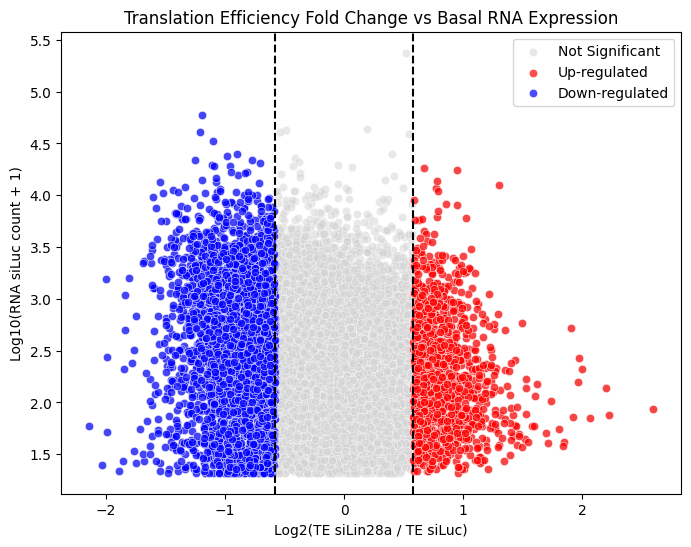

In [27]:
# 1-2. 타겟 유전자 분류 (기준을 1.5배 변화인 0.58로 조금 완화하여 타겟을 더 많이 확보)
threshold = 0.58
te_up = cnts[cnts['TE_log2FC'] >= threshold]
te_down = cnts[cnts['TE_log2FC'] <= -threshold]
print(f"TE가 증가한 유전자 수: {len(te_up)}")
print(f"TE가 감소한 유전자 수: {len(te_down)}")

# Volcano Plot 시각화
plt.figure(figsize=(8, 6))
sns.scatterplot(x=cnts['TE_log2FC'], y=np.log10(cnts['RNA_siLuc']+1), color='lightgrey', alpha=0.5, label='Not Significant')
sns.scatterplot(x=te_up['TE_log2FC'], y=np.log10(te_up['RNA_siLuc']+1), color='red', alpha=0.7, label='Up-regulated')
sns.scatterplot(x=te_down['TE_log2FC'], y=np.log10(te_down['RNA_siLuc']+1), color='blue', alpha=0.7, label='Down-regulated')

plt.xlabel('Log2(TE siLin28a / TE siLuc)')
plt.ylabel('Log10(RNA siLuc count + 1)')
plt.title('Translation Efficiency Fold Change vs Basal RNA Expression')
plt.axvline(-threshold, color='k', linestyle='--')
plt.axvline(threshold, color='k', linestyle='--')
plt.legend()
plt.show()

GTF 파일에서 유전자 이름을 읽어오는 중입니다... (몇 초 정도 소요됩니다)
TE 증가 유전자 개수: 1251개
이름 변환 성공: 1251개


/tmp/ipykernel_2406/3283417272.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=res_up, x='-log10(P-value)', y='Term', palette='Reds_r')


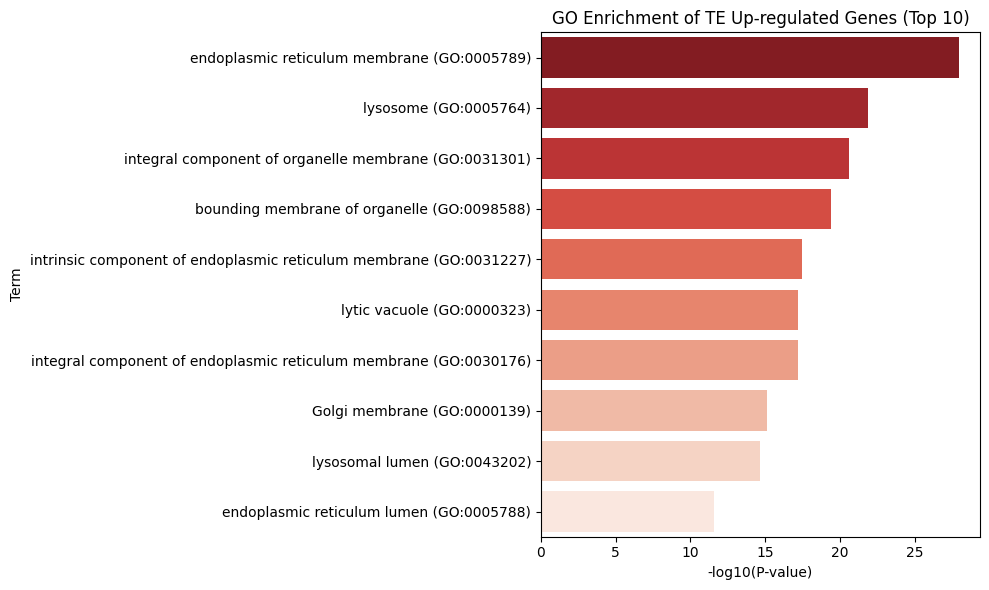

In [28]:
# 1-3. TE Up-regulated (증가한) 유전자들에 대한 GO Enrichment 분석
import gseapy as gp

# 1. GTF 파일에서 ENSMUSG ID -> Gene Symbol 매핑 사전(Dictionary) 만들기
print("GTF 파일에서 유전자 이름을 읽어오는 중입니다... (몇 초 정도 소요됩니다)")
gene_map = {}
with open('gencode.gtf', 'r') as f:
    for line in f:
        if line.startswith('#'): continue
        parts = line.split('\t')

        # gene 정보가 있는 줄에서만 추출
        if len(parts) > 8 and parts[2] == 'gene':
            info = parts[8]
            try:
                g_id = info.split('gene_id "')[1].split('"')[0].split('.')[0]
                g_name = info.split('gene_name "')[1].split('"')[0]
                gene_map[g_id] = g_name
            except IndexError:
                pass

# 2. TE가 '증가'한(te_up) 유전자들의 ID를 Gene Symbol로 변환
gene_list_up_ensembl = te_up['Geneid'].apply(lambda x: x.split('.')[0]).tolist()
gene_list_up_symbol = [gene_map[g] for g in gene_list_up_ensembl if g in gene_map]

print(f"TE 증가 유전자 개수: {len(gene_list_up_ensembl)}개")
print(f"이름 변환 성공: {len(gene_list_up_symbol)}개")

if len(gene_list_up_symbol) > 0:
    # 3. ER 등의 세포 소기관을 보기 위해 Cellular Component 데이터베이스 사용
    enr_up = gp.enrichr(gene_list=gene_list_up_symbol,
                        gene_sets='GO_Cellular_Component_2021',
                        organism='mouse',
                        outdir=None)

    if enr_up.results.empty:
         print("결과가 없습니다.")
    else:
        res_up = enr_up.results.head(10).copy()
        res_up['-log10(P-value)'] = -np.log10(res_up['P-value'])

        plt.figure(figsize=(10, 6))
        sns.barplot(data=res_up, x='-log10(P-value)', y='Term', palette='Reds_r')
        plt.title('GO Enrichment of TE Up-regulated Genes (Top 10)')
        plt.tight_layout()
        plt.show()

TE 감소 유전자 개수: 3120개
이름 변환 성공: 3120개


/tmp/ipykernel_2406/2707426221.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=res_down, x='-log10(P-value)', y='Term', palette='Blues_r')


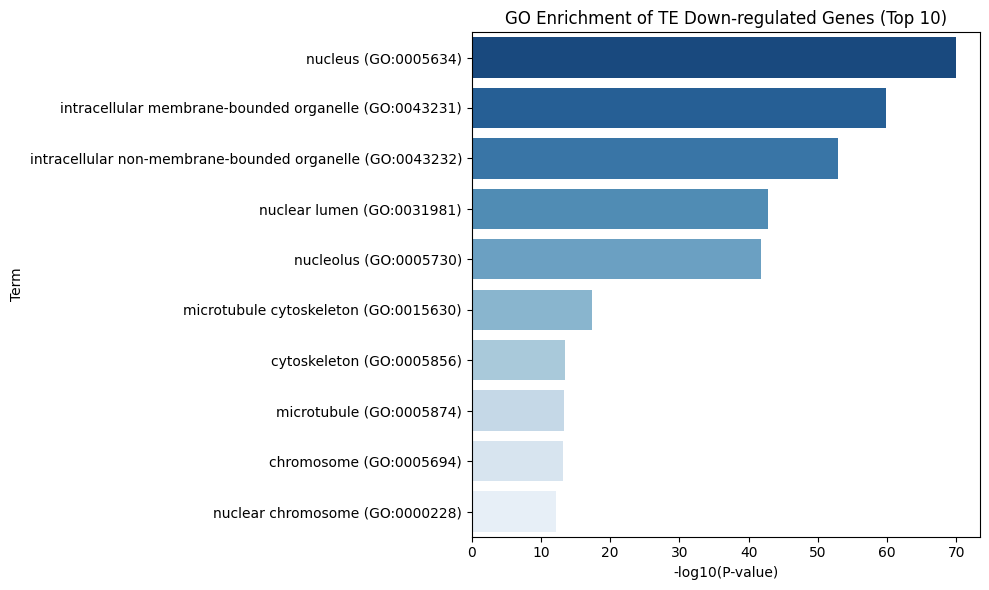

In [29]:
# 1-4. TE Down-regulated (감소한) 유전자들에 대한 GO Enrichment 분석

# 1. 위 셀에서 만들어둔 gene_map을 재사용하여 이름 변환
gene_list_down_ensembl = te_down['Geneid'].apply(lambda x: x.split('.')[0]).tolist()
gene_list_down_symbol = [gene_map[g] for g in gene_list_down_ensembl if g in gene_map]

print(f"TE 감소 유전자 개수: {len(gene_list_down_ensembl)}개")
print(f"이름 변환 성공: {len(gene_list_down_symbol)}개")

if len(gene_list_down_symbol) > 0:
    # 2. Enrichr 실행 (비교를 위해 동일하게 Cellular Component와 Biological Process 모두 확인)
    enr_down = gp.enrichr(gene_list=gene_list_down_symbol,
                          gene_sets=['GO_Cellular_Component_2021', 'GO_Biological_Process_2021'],
                          organism='mouse',
                          outdir=None)

    if enr_down.results.empty:
         print("유의미한 GO Term이 발견되지 않았습니다.")
    else:
        res_down = enr_down.results.head(10).copy()
        res_down['-log10(P-value)'] = -np.log10(res_down['P-value'])

        # 3. 시각화 (감소한 유전자이므로 파란색 계열 사용)
        plt.figure(figsize=(10, 6))
        sns.barplot(data=res_down, x='-log10(P-value)', y='Term', palette='Blues_r')
        plt.title('GO Enrichment of TE Down-regulated Genes (Top 10)')
        plt.tight_layout()
        plt.show()
else:
    print("TE가 감소한 유전자가 없습니다.")